# Teacher Feedback Data Exploration

This notebook explores the teacher feedback data to identify interesting patterns for inclusion in S5_Pilot_Statistical_Analysis.ipynb

## Variable Descriptions

| Variable name | English | German | Scale English | Scale German |
|--------------|---------|---------|---------------|---------------|
| **engagement** | How engaged did you find your students in today's lesson compared to other lessons? | Wie engagiert fandest du deine SchülerInnen in der heutigen Stunde im Vergleich zu anderen Stunden? | (1) Much less engaged, (2) Slightly less engaged, (3) Equally engaged, (4) Slightly more engaged, (5) Much more engaged | (1) Viel weniger engagiert, (2) Etwas weniger engagiert, (3) Gleich engagiert, (4) Etwas mehr engagiert, (5) Viel mehr engagiert |
| **questions** | In your opinion, how many relevant questions did your students ask during today's lesson? | Wie viele relevanten Fragen haben deine SchülerInnen deiner Meinung nach in der heutigen Stunde gestellt? | (1) No relevant questions, (2) Very few relevant questions, (3) Some relevant questions, (4) Many relevant questions, (5) Very many relevant questions | (1) Keine relevanten Fragen, (2) Sehr wenige relevante Fragen, (3) Einige relevante Fragen, (4) Viele relevante Fragen, (5) Sehr viele relevante Fragen |
| **difficulty_1** | How easy was it to guide the students through the lesson in terms of: - The content | Wie einfach war es die SchülerInnen durch die Stunde zu leiten im Bezug auf: - Den Inhalt | (1) Very difficult, (2) Rather difficult, (3) Moderate, (4) Rather easy, (5) Very easy | (1) Sehr schwierig, (2) Eher schwierig, (3) Mittel, (4) Eher einfach, (5) Sehr einfach |
| **difficulty_2** | How easy was it to guide the students through the lesson in terms of: - The students' behavior | Wie einfach war es die SchülerInnen durch die Stunde zu leiten im Bezug auf: - Das Verhalten der SchülerInnen | (1) Very difficult, (2) Rather difficult, (3) Moderate, (4) Rather easy, (5) Very easy | (1) Sehr schwierig, (2) Eher schwierig, (3) Mittel, (4) Eher einfach, (5) Sehr einfach |
| **learning** | How much do you think your students learned in today's lesson? | Wie viel haben deine SchülerInnen deiner Meinung nach in der heutigen Unterrichtsstunde gelernt? | (1) Learned nothing, (2) Learned a little, (3) Learned something, (4) Learned a lot, (5) Learned a great deal | (1) Nicht gelernt, (2) Wenig gelernt, (3) Etwas gelernt, (4) Viel gelernt, (5) Sehr viel gelernt |
| **postitive** | What two things did you like about today's lesson? | Welche zwei Dinge haben dir in der heutigen Stunde gut gefallen? | Open ended | Open ended |
| **negative** | What two things did you find difficult in today's lesson, or what would you have liked to have done differently? | Welche zwei Dinge fandest du in der heutigen Stunde schwierig oder hättest du gerne anders gemacht? | Open ended | Open ended |
| **qualitative** | There is space here if you would like to tell us anything else. | Hier ist Platz, falls du uns sonst noch etwas mitteilen möchtest. | Open ended | Open ended |
| **LLM_helpful** | How helpful did you find the last language interaction with Marty for the students' learning? | Wie hilfreich für das Lernen der SchülerInnen fandest du die letzte Sprachinteraktion mit Marty? | (1) Not helpful at all, (2) Somewhat helpful, (3) Helpful, (4) Very helpful, (5) I can't say | (1) Überhaupt nicht hilfreich, (2) Etwas hilfreich, (3) Hilfreich, (4) Sehr hilfreich, (5) Kann ich nicht beurteilen |
| **LLM_easy** | How easy did you find the last language interaction for the students? | Wie einfach fandest du die letzte Sprachinteraktion für die SchülerInnen? | (1) Very difficult, (2) Rather difficult, (3) Moderate, (4) Rather easy, (5) Very easy, (6) I cannot judge | (1) Sehr schwierig, (2) Eher schwierig, (3) Mittel, (4) Eher einfach, (5) Sehr einfach, (6) Kann ich nicht beurteilen |
| **LLM_engaging** | How entertaining did you find the last language interaction for the students? | Wie unterhaltsam fandest du die letzte Sprachinteraktion für die SchülerInnen? | (1) Not entertaining at all, (2) Not very entertaining, (3) Neither entertaining nor not entertaining, (4) Somewhat entertaining, (5) Very entertaining, (6) I can't say | (1) Überhaupt nicht unterhaltsam, (2) Eher nicht unterhaltsam, (3) Weder noch, (4) Eher unterhaltsam, (5) Sehr unterhaltsam, (6) Kann ich nicht beurteilen |

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [144]:
# Load data (skip second row which contains German question text)
data_path = Path('Data/Qualtrics/BuildbotAnalysis - BuildBots_engagement_teachers.csv')
df = pd.read_csv(data_path, skiprows=[1])

# Convert numeric columns to proper type
numeric_cols = ['engagement', 'questions', 'difficulty_1 - content', 
                'difficulty_2 - behavior', 'learning',
                'LLM_helpful', 'LLM_easy', 'LLM_engaging',
                'project_like', 'project_learning', 'project_difficulty_1',
                'project_difficulty_2', 'project_positive', 'project_value']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset Shape: (13, 23)

Columns:
['Time point', 'Duration (in seconds)', 'Participant ID', 'engagement', 'questions', 'difficulty_1 - content', 'difficulty_2 - behavior', 'learning', 'postitive', 'negative', 'qualitative', 'LLM_helpful', 'LLM_easy', 'LLM_engaging', 'project_like', 'project_learning', 'project_difficulty_1', 'project_difficulty_2', 'project_positive', 'project_value', 'project_challenging', 'project_change', 'qualitative.1']

First few rows:


,Time point,Duration (in seconds),Participant ID,engagement,questions,difficulty_1 - content,difficulty_2 - behavior,learning,postitive,negative,...,LLM_engaging,project_like,project_learning,project_difficulty_1,project_difficulty_2,project_positive,project_value,project_challenging,project_change,qualitative.1
0,T1,187,1,4,2,4,4,4,"The construction of the robot, group work on t...","The questionnaire was very long, so it took a ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T1,330,2,3,2,5,4,4,The well-prepared presentation and the interes...,"As expected, the random groups did indeed caus...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,T2,522,1,4,4,2,3,4,The motivation of the LPs in building the robo...,It was difficult for me to help build the robo...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T2,286,2,3,3,3,4,4,The learning partners were able to start build...,"Unfortunately, the worksheets stored behind th...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,T3,253,2,4,3,3,3,4,Little theory and therefore a lot of reading o...,"Regardless of the Marty project, there are alw...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
# Data info
print("Data Info:")
df.info()

print("\n\nTimepoint Distribution:")
print(df['Time point'].value_counts().sort_index())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Time point               13 non-null     object 
 1   Duration (in seconds)    13 non-null     int64  
 2   Participant ID           13 non-null     int64  
 3   engagement               13 non-null     int64  
 4   questions                13 non-null     int64  
 5   difficulty_1 - content   13 non-null     int64  
 6   difficulty_2 - behavior  13 non-null     int64  
 7   learning                 13 non-null     int64  
 8   postitive                13 non-null     object 
 9   negative                 13 non-null     object 
 10  qualitative              3 non-null      object 
 11  LLM_helpful              2 non-null      float64
 12  LLM_easy                 2 non-null      float64
 13  LLM_engaging             2 non-null      float64
 14  project_like     

In [146]:
# Analyze key variables - show individual values per timepoint
key_vars = ['engagement', 'questions', 'difficulty_1 - content', 
            'difficulty_2 - behavior', 'learning']

print("=== KEY VARIABLES BY TIMEPOINT ===")
print("(Showing individual teacher ratings)\n")

for var in key_vars:
    if var in df.columns:
        print(f"\n{var}:")
        for tp in sorted(df['Time point'].unique()):
            values = df[df['Time point'] == tp][var].dropna().tolist()
            if values:
                print(f"  {tp}: {values}")

=== KEY VARIABLES BY TIMEPOINT ===
(Showing individual teacher ratings)


engagement:
  T1: [4, 3]
  T2: [4, 3]
  T3: [4]
  T4: [5, 3]
  T5: [5, 4]
  T6: [2, 3]
  T7: [2, 5]

questions:
  T1: [2, 2]
  T2: [4, 3]
  T3: [3]
  T4: [4, 2]
  T5: [4, 3]
  T6: [5, 2]
  T7: [2, 4]

difficulty_1 - content:
  T1: [4, 5]
  T2: [2, 3]
  T3: [3]
  T4: [3, 4]
  T5: [4, 3]
  T6: [2, 1]
  T7: [3, 4]

difficulty_2 - behavior:
  T1: [4, 4]
  T2: [3, 4]
  T3: [3]
  T4: [5, 3]
  T5: [4, 4]
  T6: [3, 3]
  T7: [3, 2]

learning:
  T1: [4, 4]
  T2: [4, 4]
  T3: [4]
  T4: [4, 3]
  T5: [5, 4]
  T6: [4, 3]
  T7: [3, 4]


In [147]:
# LLM-related variables (T7 only)
df_t7 = df[df['Time point'] == 'T7'].copy()
print(f"N teachers at T7: {len(df_t7)}")

llm_vars = ['LLM_helpful', 'LLM_easy', 'LLM_engaging']

print("\n=== LLM-RELATED VARIABLES (T7 only) ===")
print("(Individual teacher ratings)\n")
for var in llm_vars:
    if var in df_t7.columns:
        values = df_t7[var].dropna()
        print(f"{var}: {values.tolist()}")

N teachers at T7: 2

=== LLM-RELATED VARIABLES (T7 only) ===
(Individual teacher ratings)

LLM_helpful: [3.0, 3.0]
LLM_easy: [5.0, 2.0]
LLM_engaging: [4.0, 4.0]


In [148]:
# Project evaluation variables (T7 only)
project_vars = ['project_like', 'project_learning', 'project_difficulty_1', 
                'project_difficulty_2', 'project_positive', 'project_value']

print("=== PROJECT EVALUATION (T7 only) ===")
print("(Individual teacher ratings)\n")
for var in project_vars:
    if var in df_t7.columns:
        values = df_t7[var].dropna()
        print(f"{var}: {values.tolist()}")

=== PROJECT EVALUATION (T7 only) ===
(Individual teacher ratings)

project_like: [4.0, 3.0]
project_learning: [3.0, 4.0]
project_difficulty_1: [3.0, 2.0]
project_difficulty_2: [3.0, 3.0]
project_positive: []
project_value: []


In [149]:
# Project evaluation variables (T7 only)
project_vars = ['project_like', 'project_learning', 'project_difficulty_1', 
                'project_difficulty_2', 'project_positive', 'project_value']

print("=== PROJECT EVALUATION (T7 only) ===")
for var in project_vars:
    if var in df_t7.columns:
        values = df_t7[var].dropna()
        print(f"\n{var}:")
        print(f"  Values: {values.tolist()}")
        if len(values) > 0:
            print(f"  Mean: {values.mean():.2f}")
            print(f"  Std: {values.std():.2f}")

=== PROJECT EVALUATION (T7 only) ===

project_like:
  Values: [4.0, 3.0]
  Mean: 3.50
  Std: 0.71

project_learning:
  Values: [3.0, 4.0]
  Mean: 3.50
  Std: 0.71

project_difficulty_1:
  Values: [3.0, 2.0]
  Mean: 2.50
  Std: 0.71

project_difficulty_2:
  Values: [3.0, 3.0]
  Mean: 3.00
  Std: 0.00

project_positive:
  Values: []

project_value:
  Values: []


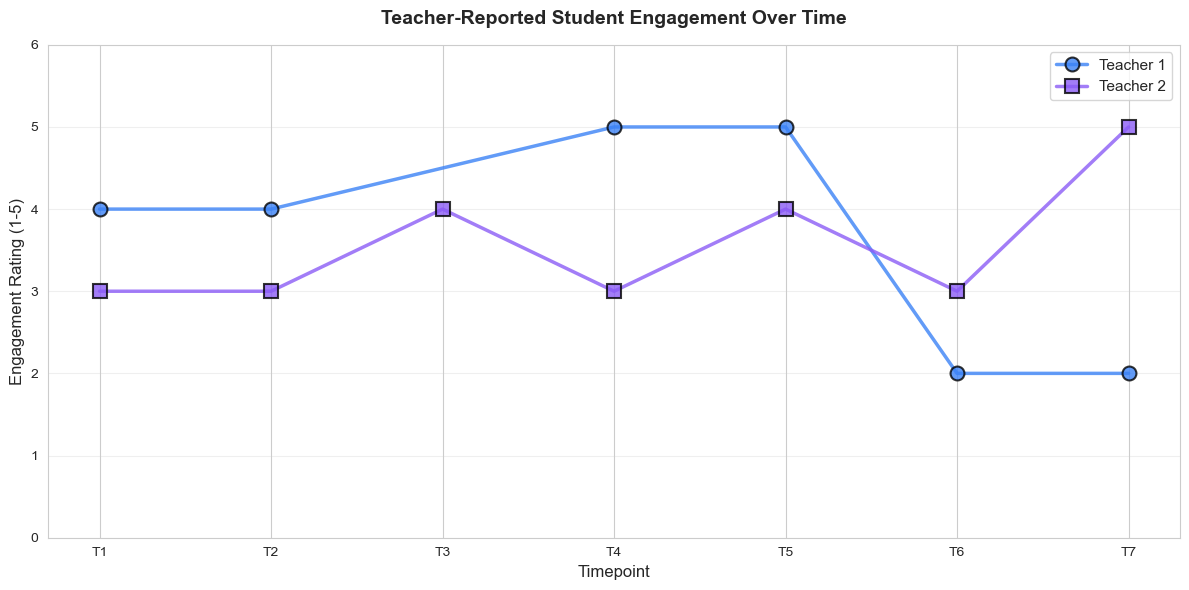

In [150]:
# Visualization 1: Teacher Engagement Ratings Over Time
# Connect dots for each teacher with different colors
plt.figure(figsize=(12, 6))

timepoints = sorted(df['Time point'].unique())
teachers = df['Participant ID'].unique()
colors = ['#3b82f6', '#8b5cf6']  # Blue and Purple
markers = ['o', 's']  # Circle and square

for idx, teacher in enumerate(teachers):
    teacher_data = df[df['Participant ID'] == teacher].sort_values('Time point')
    x_vals = [timepoints.index(tp) for tp in teacher_data['Time point']]
    y_vals = teacher_data['engagement'].values
    
    plt.plot(x_vals, y_vals, marker=markers[idx], markersize=10, linewidth=2.5,
             color=colors[idx], alpha=0.8, label=f'Teacher {teacher}',
             markeredgecolor='black', markeredgewidth=1.5)

plt.title('Teacher-Reported Student Engagement Over Time', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Timepoint', fontsize=12)
plt.ylabel('Engagement Rating (1-5)', fontsize=12)
plt.ylim(0, 6)
plt.xticks(range(len(timepoints)), timepoints)
plt.grid(axis='y', alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

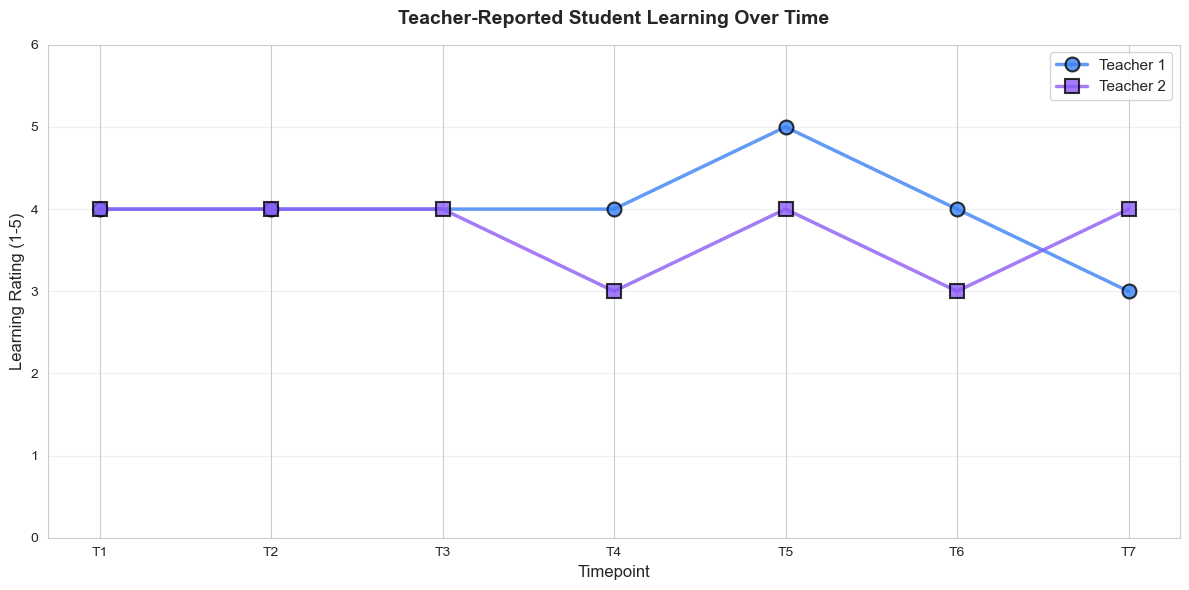

In [151]:
# Visualization 2: Teacher-Reported Student Learning
# Connect dots for each teacher with different colors
plt.figure(figsize=(12, 6))

timepoints = sorted(df['Time point'].unique())
teachers = df['Participant ID'].unique()
colors = ['#3b82f6', '#8b5cf6']  # Blue and Purple
markers = ['o', 's']  # Circle and square

for idx, teacher in enumerate(teachers):
    teacher_data = df[df['Participant ID'] == teacher].sort_values('Time point')
    x_vals = [timepoints.index(tp) for tp in teacher_data['Time point']]
    y_vals = teacher_data['learning'].values
    
    plt.plot(x_vals, y_vals, marker=markers[idx], markersize=10, linewidth=2.5,
             color=colors[idx], alpha=0.8, label=f'Teacher {teacher}',
             markeredgecolor='black', markeredgewidth=1.5)

plt.title('Teacher-Reported Student Learning Over Time', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Timepoint', fontsize=12)
plt.ylabel('Learning Rating (1-5)', fontsize=12)
plt.ylim(0, 6)
plt.xticks(range(len(timepoints)), timepoints)
plt.grid(axis='y', alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

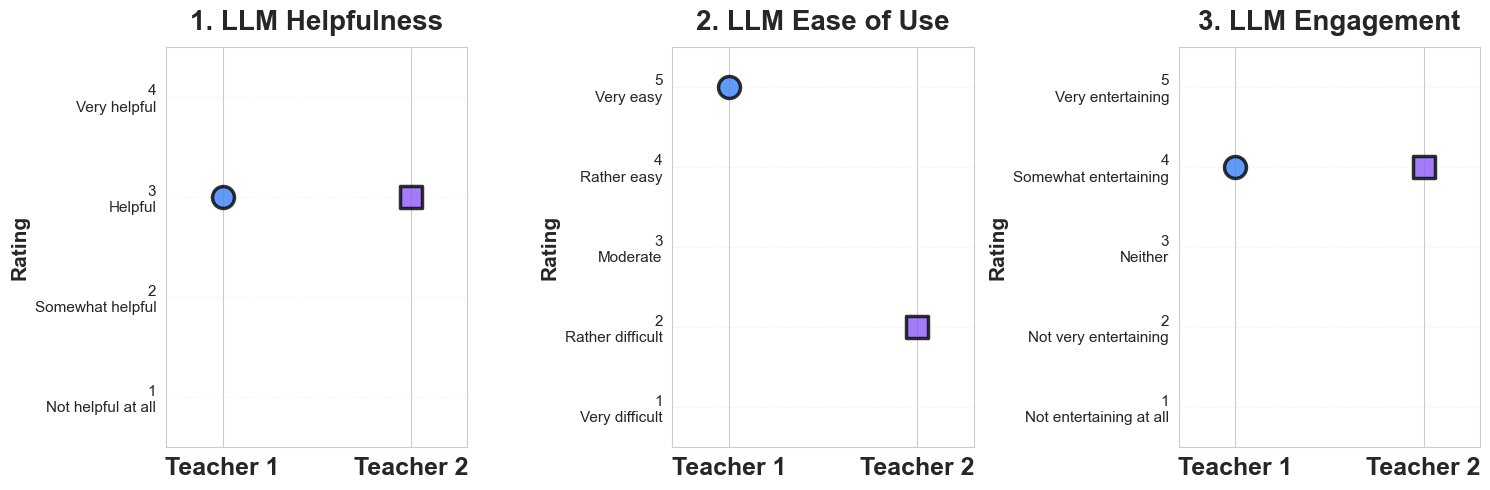

In [152]:
# Visualization 3: LLM Feedback (T7 only)
# Three separate graphs with rating on y-axis, teachers on x-axis
if len(df_t7) > 0:
    # Define scale labels (excluding "I can't say" options)
    helpful_labels = {1: 'Not helpful at all', 2: 'Somewhat helpful', 3: 'Helpful', 4: 'Very helpful'}
    easy_labels = {1: 'Very difficult', 2: 'Rather difficult', 3: 'Moderate', 4: 'Rather easy', 5: 'Very easy'}
    engaging_labels = {1: 'Not entertaining at all', 2: 'Not very entertaining', 3: 'Neither', 4: 'Somewhat entertaining', 5: 'Very entertaining'}
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    llm_vars = ['LLM_helpful', 'LLM_easy', 'LLM_engaging']
    titles = ['1. LLM Helpfulness', '2. LLM Ease of Use', '3. LLM Engagement']
    label_dicts = [helpful_labels, easy_labels, engaging_labels]
    teachers = sorted(df_t7['Participant ID'].unique())
    colors = ['#3b82f6', '#8b5cf6']  # Blue and Purple
    markers = ['o', 's']  # Circle and square
    
    for plot_idx, (var, title, labels_map) in enumerate(zip(llm_vars, titles, label_dicts)):
        ax = axes[plot_idx]
        
        # Get valid scale points (exclude "I can't say" responses)
        possible_values = sorted(labels_map.keys())
        min_rating = min(possible_values)
        max_rating = max(possible_values)
        
        # Plot each teacher's rating
        for teacher_idx, teacher in enumerate(teachers):
            teacher_data = df_t7[df_t7['Participant ID'] == teacher]
            rating = teacher_data[var].values[0] if len(teacher_data[var].dropna()) > 0 else None
            
            # Only plot if rating is valid (not "I can't say")
            if rating is not None and rating in possible_values:
                ax.scatter([teacher_idx], [rating], s=250, alpha=0.8, 
                          color=colors[teacher_idx], edgecolor='black', linewidth=2.5,
                          marker=markers[teacher_idx], zorder=3,
                          label=f'Teacher {teacher}' if plot_idx == 0 else '')
        
        ax.set_title(title, fontweight='bold', fontsize=20, pad=12)
        ax.set_xlabel('', fontsize=15)
        ax.set_ylabel('Rating', fontsize=15, fontweight='bold')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Teacher 1', 'Teacher 2'], fontsize=18, fontweight='bold')
        ax.set_ylim(min_rating - 0.5, max_rating + 0.5)
        ax.set_yticks(possible_values)
        ax.set_yticklabels([f"{v}\n{labels_map[v]}" for v in possible_values], fontsize=11)
        ax.grid(axis='y', alpha=0.3, linestyle=':')
        ax.set_xlim(-0.3, 1.3)
    

    
    plt.tight_layout()
    plt.show()
else:
    print("No T7 data available")

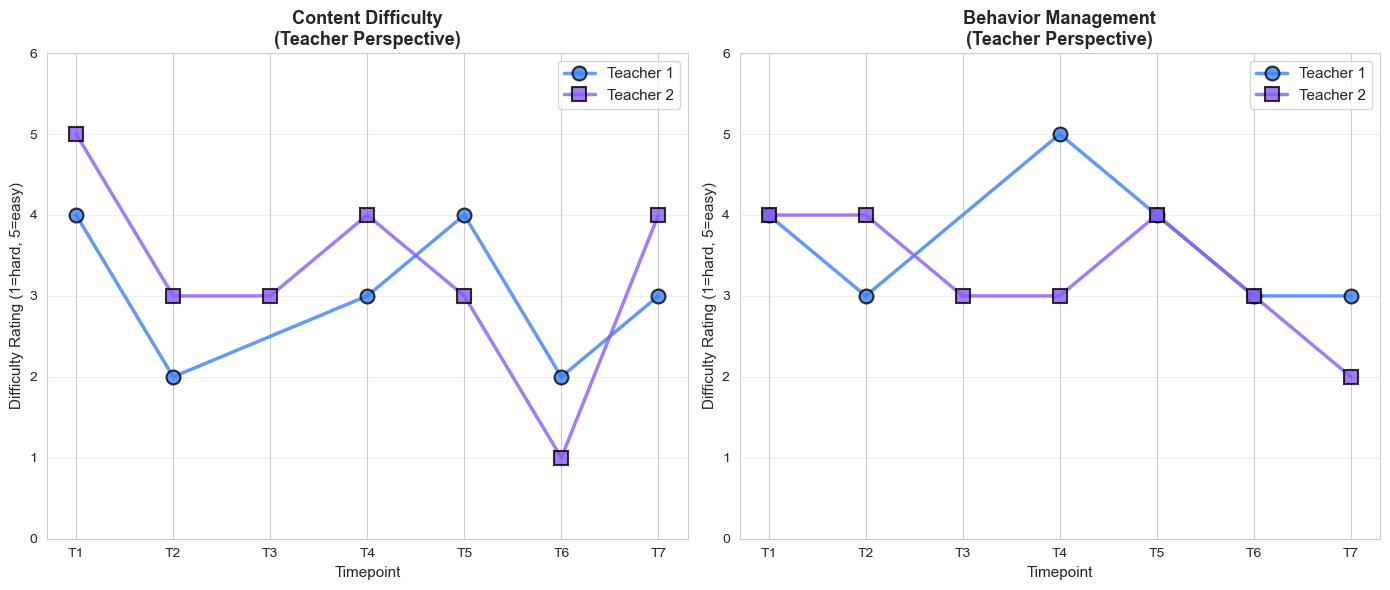

In [153]:
# Visualization 4: Difficulty Ratings Over Time
# Connect dots for each teacher with different colors
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

timepoints = sorted(df['Time point'].unique())
teachers = df['Participant ID'].unique()
colors = ['#3b82f6', '#8b5cf6']  # Blue and Purple
markers = ['o', 's']  # Circle and square

# Content difficulty
ax1 = axes[0]
for idx, teacher in enumerate(teachers):
    teacher_data = df[df['Participant ID'] == teacher].sort_values('Time point')
    x_vals = [timepoints.index(tp) for tp in teacher_data['Time point']]
    y_vals = teacher_data['difficulty_1 - content'].values
    
    ax1.plot(x_vals, y_vals, marker=markers[idx], markersize=10, linewidth=2.5,
             color=colors[idx], alpha=0.8, label=f'Teacher {teacher}',
             markeredgecolor='black', markeredgewidth=1.5)

ax1.set_title('Content Difficulty\n(Teacher Perspective)', fontweight='bold', fontsize=13)
ax1.set_xlabel('Timepoint', fontsize=11)
ax1.set_ylabel('Difficulty Rating (1=hard, 5=easy)', fontsize=11)
ax1.set_ylim(0, 6)
ax1.set_xticks(range(len(timepoints)))
ax1.set_xticklabels(timepoints, rotation=0)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(fontsize=11)

# Behavior difficulty
ax2 = axes[1]
for idx, teacher in enumerate(teachers):
    teacher_data = df[df['Participant ID'] == teacher].sort_values('Time point')
    x_vals = [timepoints.index(tp) for tp in teacher_data['Time point']]
    y_vals = teacher_data['difficulty_2 - behavior'].values
    
    ax2.plot(x_vals, y_vals, marker=markers[idx], markersize=10, linewidth=2.5,
             color=colors[idx], alpha=0.8, label=f'Teacher {teacher}',
             markeredgecolor='black', markeredgewidth=1.5)

ax2.set_title('Behavior Management\n(Teacher Perspective)', fontweight='bold', fontsize=13)
ax2.set_xlabel('Timepoint', fontsize=11)
ax2.set_ylabel('Difficulty Rating (1=hard, 5=easy)', fontsize=11)
ax2.set_ylim(0, 6)
ax2.set_xticks(range(len(timepoints)))
ax2.set_xticklabels(timepoints, rotation=0)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [154]:
# Summary: Show all ratings by timepoint in a table format
print("=== SUMMARY BY TIMEPOINT ===")
print("(Individual teacher ratings)\n")

for tp in sorted(df['Time point'].unique()):
    print(f"\n{tp}:")
    tp_data = df[df['Time point'] == tp][key_vars]
    print(tp_data.to_string(index=False))

=== SUMMARY BY TIMEPOINT ===
(Individual teacher ratings)


T1:
 engagement  questions  difficulty_1 - content  difficulty_2 - behavior  learning
          4          2                       4                        4         4
          3          2                       5                        4         4

T2:
 engagement  questions  difficulty_1 - content  difficulty_2 - behavior  learning
          4          4                       2                        3         4
          3          3                       3                        4         4

T3:
 engagement  questions  difficulty_1 - content  difficulty_2 - behavior  learning
          4          3                       3                        3         4

T4:
 engagement  questions  difficulty_1 - content  difficulty_2 - behavior  learning
          5          4                       3                        5         4
          3          2                       4                        3         3

T5:
 engagement  q

In [155]:
# Qualitative feedback themes
print("=== QUALITATIVE FEEDBACK ===")
print("\nPositive Feedback:")
print("-" * 80)
for i, feedback in enumerate(df['postitive'].dropna(), 1):
    print(f"{i}. {feedback}")

print("\n\nNegative Feedback / Challenges:")
print("-" * 80)
for i, feedback in enumerate(df['negative'].dropna(), 1):
    print(f"{i}. {feedback}")

=== QUALITATIVE FEEDBACK ===

Positive Feedback:
--------------------------------------------------------------------------------
1. The construction of the robot, group work on the different robots
2. The well-prepared presentation and the interest shown by the learning partners.
3. The motivation of the LPs in building the robot.
The exercises for the presentation, as it became clear in the subsequent discussion that the LPs had understood.
4. The learning partners were able to start building right away today.
The Lernspadener students were very focused when it came to the theoretical part.
5. Little theory and therefore a lot of reading of the assembly instructions and building
6. The opportunity for LPs to explore Marty's features on their own.
7. Short presentation and embedded videos, everyone was focused on the task at hand.
8. The content was not too difficult, which meant that the learning partners were more motivated and achieved learning success. The learning partners were a

## Key Findings for S5

Based on this exploration, consider including:

1. **Teacher engagement ratings** - Shows how teachers perceived student engagement across timepoints
2. **Learning ratings** - Teacher perspective on student learning
3. **LLM-specific feedback (T7)** - Teacher ratings of the LLM interaction
4. **Difficulty ratings** - Content vs behavior management challenges

The most relevant for the LLM Frame paper would be the **T7 LLM-specific feedback** showing teacher perspectives on the LLM interaction.